# Cybersec OpenEnv: end-to-end RL train + eval (final defaults)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/LonelyGuy-SE1/cybersec_env/blob/main/notebooks/cybersec_grpo.ipynb)

**Canonical training path** (repo): this notebook. Install the env from the
[`cybersec` OpenEnv Space](https://huggingface.co/spaces/Lonelyguyse1/cybersec), then **Run all**.

1. Install the env package from the **HF Space** (optional: set `HF_TOKEN` in Colab secrets to avoid hub rate-limit warnings).
2. Baselines: `RandomPolicy` + `HeuristicPolicy` over N seeds on all scenarios.
3. Build the GRPO dataset (heuristic rollouts, pickled snapshots).
4. **Base LLM (no LoRA) eval** then **QLoRA + GRPO** (Unsloth + TRL) with **iter-4-style** hyperparams: more steps, 6 candidates/group, higher temperature, KL `beta`, tuned LR — aimed at **non-collapsed** per-scenario return variance.
5. **Trained-adapter** eval (same seeds / scenarios as base).
6. Plots, summary table, **strict canaries** (incl. ≥2/3 training scenarios with `std_return > 0.1`, cap on `MONITOR` parse-fallback rate).
7. **Optional** full-horizon **episode trace** (heuristic demo + LLM after eval).

**Target compute:** Colab **T4** (fp16 on GPU, not bf16). With default `grpo_max_steps=300`, wall
clock is often **2–3+ hours**. **`_artifacts/run_manifest.json`** is written at start and
updated (dataset + train timing + log row count) so you can post-mortem a bad run. For a
smoke run, lower `grpo_max_steps` and episode counts.


## 0. Install (from the HF Space)


In [1]:
%%capture
# Install the env from the deployed HF Space (canonical source). Optional:
# in Colab, add HF_TOKEN to User secrets to silence unauthenticated hub
# warnings and avoid rate limits when downloading the base model.
import os, sys, subprocess, importlib
from pathlib import Path

HF_SPACE_REPO_ID = "Lonelyguyse1/cybersec"
HF_SPACE_REVISION = "main"
PKG_STAGE = Path("/content/cybersec_env_pkg") if "google.colab" in sys.modules else Path("..").resolve() / "cybersec"

# Local checkout: we already have the package on disk (running off a
# developer machine). Skip the snapshot_download dance entirely.
if "google.colab" in sys.modules:
    !pip install -q "huggingface_hub>=0.24"
    from huggingface_hub import snapshot_download
    PKG_STAGE.mkdir(parents=True, exist_ok=True)
    snapshot_download(
        repo_id=HF_SPACE_REPO_ID,
        repo_type="space",
        revision=HF_SPACE_REVISION,
        local_dir=str(PKG_STAGE),
        local_dir_use_symlinks=False,
    )
    !pip install -q -e {PKG_STAGE}
else:
    print(f"using in-tree package at {PKG_STAGE}")

# Pinned for the free Colab T4 (CUDA 12.x). Unsloth ships its own torch
# wheel so install it before TRL/peft/accelerate.
!pip install -q "unsloth[cu121] @ git+https://github.com/unslothai/unsloth.git"
!pip install -q --upgrade trl peft accelerate bitsandbytes
!pip install -q matplotlib pandas


In [2]:
import os

os.rename('cybersec_env_pkg', 'cybersec')


## 1. Imports & config


In [3]:
from __future__ import annotations

# Iter-1's notebook output was buried under thousands of lines of identical
# `max_new_tokens / attention_mask` deprecation warnings. Silence the known
# noise *before* importing torch / transformers so the cell outputs are
# actually readable.
import warnings, logging
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="transformers")
warnings.filterwarnings("ignore", category=DeprecationWarning)
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("accelerate").setLevel(logging.ERROR)
logging.getLogger("peft").setLevel(logging.ERROR)
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
logging.getLogger("trl").setLevel(logging.WARNING)
logging.getLogger("websockets").setLevel(logging.WARNING)

import base64
import copy
import gc
import json
import math
import os
import pickle
import random
import sys
import time
from pathlib import Path

import matplotlib
matplotlib.use("Agg") if "google.colab" not in sys.modules else None
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from datasets import Dataset

from cybersec import (
    ActionType,
    CybersecAction,
    CybersecEnv,
    CybersecEnvironment,
    list_eval_scenarios,
    list_scenarios,
    list_train_scenarios,
)
from cybersec.baselines import (
    HeuristicPolicy,
    RandomPolicy,
    aggregate_results,
    run_episode,
)
from cybersec.training.rewards import (
    SYSTEM_PROMPT,
    default_reward_funcs,
    parse_first_json_object,
    parsed_action,
    render_observation,
    restore_env,
    snapshot_env,
)

# ---------------------------------------------------------------------------
# Final training defaults (Colab T4, fp16 — see GRPO cell; bf16 off).
# Budget: max_steps (not epochs) is the main GRPO limit; num_train_epochs=1.
# Smoke: grpo_max_steps 30–50, n_baseline / n_post / n_dataset_seeds 5–10, run_base_llm_eval False.
# Tighter logs: grpo_logging_steps 1 (noisy) or 5 (default).
# ---------------------------------------------------------------------------
MODE = {
    "n_baseline_episodes":   30,
    "n_dataset_seeds":       30,
    "max_dataset_rows":      1500,
    "grpo_num_train_epochs": 1,
    "grpo_max_steps":        300,
    "grpo_num_generations":  6,
    "grpo_per_device_bs":    2,
    "grpo_grad_accum":       4,
    "grpo_logging_steps":    5,
    "grpo_save_steps":       50,
    "grpo_temperature":      1.2,
    "grpo_beta":             0.04,
    "grpo_learning_rate":    3e-6,
    "n_post_train_episodes": 30,
    "run_base_llm_eval":     True,
    # Set to True to also run baseline + post-train eval against the
    # deployed HF Space env over WebSocket. Off by default to keep the
    # default Run-All hermetic and offline-friendly.
    "use_remote_env":        False,
    "remote_env_url":        "https://lonelyguyse1-cybersec.hf.space",
}

ARTIFACTS = Path("_artifacts")
ARTIFACTS.mkdir(exist_ok=True)

ADAPTER_DIR        = ARTIFACTS / "qwen_cybersec_lora"
TRAIN_LOG          = ARTIFACTS / "training_log.json"
BASELINE_JSON      = ARTIFACTS / "baseline_metrics.json"
POST_JSON          = ARTIFACTS / "post_train_metrics.json"
HELDOUT_JSON       = ARTIFACTS / "heldout_metrics.json"
BASELINE_PLOT      = ARTIFACTS / "baseline_curves.png"
BEFORE_AFTER       = ARTIFACTS / "before_after_curves.png"
TRAIN_DIAGNOSTICS  = ARTIFACTS / "training_diagnostics.png"
SUMMARY_MD         = ARTIFACTS / "summary_table.md"
TRAJECTORY_JSON    = ARTIFACTS / "trajectory_dataset.jsonl"

MODEL_NAME      = "Qwen/Qwen2.5-1.5B-Instruct"
MAX_PROMPT_LEN  = 1024
MAX_NEW_TOKENS  = 48

TRAIN_SCENARIOS = list_train_scenarios()
HELDOUT_SCENARIOS = list_eval_scenarios()
ALL_SCENARIOS = list_scenarios()
SEEDS_BASELINE = list(range(MODE["n_baseline_episodes"]))
SEEDS_DATASET  = list(range(MODE["n_dataset_seeds"]))
SEEDS_POST     = list(range(MODE["n_post_train_episodes"]))

print("train scenarios:   ", TRAIN_SCENARIOS)
print("held-out scenarios:", HELDOUT_SCENARIOS)
print("MODE:")
print(json.dumps(MODE, indent=2))
if not os.environ.get("HF_TOKEN") and not os.environ.get("HUGGINGFACE_HUB_TOKEN"):
    print("Tip: set HF_TOKEN or HUGGINGFACE_HUB_TOKEN (e.g. Colab secrets) to avoid hub auth warnings when pulling models.")

# --- run_manifest.json: torch/CUDA + effective batch; extend after dataset & training ---
_eff_bs = MODE["grpo_per_device_bs"] * MODE["grpo_grad_accum"]
RUN_MANIFEST = ARTIFACTS / "run_manifest.json"
_manifest = {
    "started_at_utc":        time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
    "mode":                  MODE,
    "model_name":            MODEL_NAME,
    "max_prompt_len":        MAX_PROMPT_LEN,
    "max_new_tokens":        MAX_NEW_TOKENS,
    "torch_version":         torch.__version__,
    "cuda_available":        torch.cuda.is_available(),
    "cuda_version":          getattr(torch.version, "cuda", None),
    "device_name":           (torch.cuda.get_device_name(0) if torch.cuda.is_available() else None),
    "effective_optim_batch":  _eff_bs,
    "notes":                 "GRPO uses fp16 on GPU (bf16 False); 4-bit base via Unsloth.",
    "bf16":                  False,
    "fp16":                  bool(torch.cuda.is_available()),
}
RUN_MANIFEST.write_text(json.dumps(_manifest, indent=2, default=str))
print("--- run_manifest (partial) ---")
print("  device:", _manifest["device_name"], "| fp16:", _manifest["fp16"], "| eff. batch (acc):", _eff_bs)
print("wrote", RUN_MANIFEST)


train scenarios:    ['supply_chain_token_drift', 'federated_identity_takeover', 'insider_repo_pivot']
held-out scenarios: ['cloud_metadata_ssrf']
MODE:
{
  "n_baseline_episodes": 30,
  "n_dataset_seeds": 30,
  "max_dataset_rows": 1500,
  "grpo_num_train_epochs": 1,
  "grpo_max_steps": 300,
  "grpo_num_generations": 6,
  "grpo_per_device_bs": 2,
  "grpo_grad_accum": 4,
  "grpo_logging_steps": 5,
  "grpo_save_steps": 50,
  "grpo_temperature": 1.2,
  "grpo_beta": 0.04,
  "grpo_learning_rate": 3e-06,
  "n_post_train_episodes": 30,
  "run_base_llm_eval": true,
  "use_remote_env": false,
  "remote_env_url": "https://lonelyguyse1-cybersec.hf.space"
}
Tip: set HF_TOKEN or HUGGINGFACE_HUB_TOKEN (e.g. Colab secrets) to avoid hub auth warnings when pulling models.
--- run_manifest (partial) ---
  device: Tesla T4 | fp16: True | eff. batch (acc): 8
wrote _artifacts/run_manifest.json


## 2. Baseline: Random vs Heuristic (train + held-out scenarios)


In [4]:
# Local CybersecEnvironment for fast in-kernel rollouts. We optionally
# repeat the baseline against the deployed HF Space below as a separate
# remote-env smoke check.
env = CybersecEnvironment()
baseline_runs = {}

t0 = time.time()
for sid in ALL_SCENARIOS:
    rand = [run_episode(env, RandomPolicy(seed=s), seed=s, scenario_id=sid) for s in SEEDS_BASELINE]
    heur = [run_episode(env, HeuristicPolicy(),    seed=s, scenario_id=sid) for s in SEEDS_BASELINE]
    baseline_runs[sid] = {"random": rand, "heuristic": heur}
    print(f"{sid:<32s}  random={aggregate_results(rand)['mean_return']:7.3f}"
          f"  heuristic={aggregate_results(heur)['mean_return']:7.3f}")
print(f"baseline elapsed: {time.time()-t0:.1f}s")


supply_chain_token_drift          random=  2.156  heuristic=  2.335
federated_identity_takeover       random=  0.198  heuristic=  2.930
insider_repo_pivot                random=  2.905  heuristic=  2.410
cloud_metadata_ssrf               random=  1.723  heuristic=  2.552
baseline elapsed: 0.3s


### 2a. (Optional) Remote-env smoke check

If `MODE['use_remote_env']` is `True`, this cell runs **one** baseline
episode of the heuristic policy against the deployed HF Space env. The
purpose is to prove that the same package code, served over the OpenEnv
WebSocket protocol, returns identical-shape observations -- not to repeat
the full baseline against the network (which would be slow).


In [5]:
import asyncio

async def _remote_smoke():
    base_url = MODE["remote_env_url"]
    print(f"connecting to remote env: {base_url}")
    async with CybersecEnv(base_url=base_url) as remote:
        result = await remote.reset(seed=0, scenario_id=TRAIN_SCENARIOS[0])
        steps = 0
        cumulative = 0.0
        while not result.done and steps < 80:
            policy = HeuristicPolicy()
            action = policy.act(result.observation)
            result = await remote.step(action)
            cumulative += float(result.reward or 0.0)
            steps += 1
        print(f"remote heuristic episode: steps={steps}  cumulative_reward={cumulative:.3f}")

if MODE["use_remote_env"]:
    try:
        asyncio.run(_remote_smoke())
    except Exception as exc:
        print(f"remote env smoke failed (continuing with local): {exc!r}")
else:
    print("remote env smoke skipped (MODE['use_remote_env'] is False)")


remote env smoke skipped (MODE['use_remote_env'] is False)


### 2b. Persist baseline metrics + plot


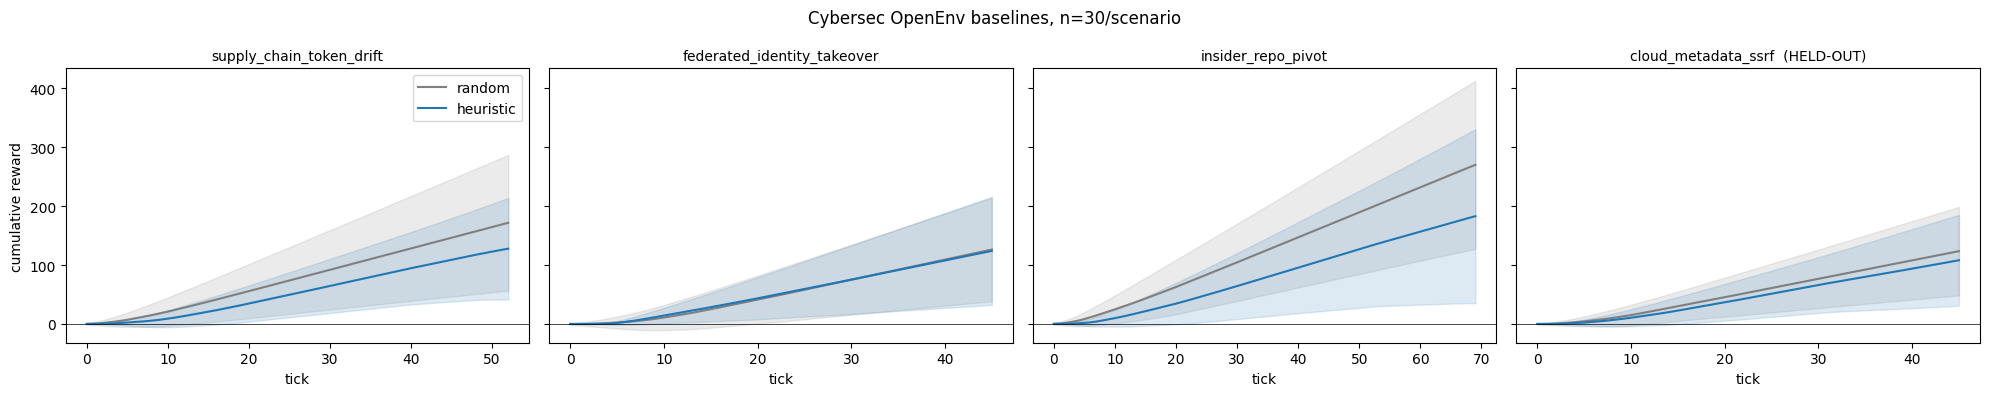

wrote _artifacts/baseline_metrics.json


In [6]:
def _padded_cumulative(curves, target_len):
    out = np.zeros((len(curves), target_len), dtype=float)
    for i, c in enumerate(curves):
        out[i, : len(c)] = c
        if len(c) < target_len:
            out[i, len(c):] = c[-1] if c else 0.0
    return np.cumsum(out, axis=1)

n_panels = len(ALL_SCENARIOS)
fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 4), sharey=True)
if n_panels == 1:
    axes = [axes]
for ax, sid in zip(axes, ALL_SCENARIOS):
    cell = baseline_runs[sid]
    horizon = max(max(len(r.reward_curve) for r in cell['random']),
                  max(len(r.reward_curve) for r in cell['heuristic']))
    for label, color in [("random", "tab:gray"), ("heuristic", "tab:blue")]:
        cumr = _padded_cumulative([r.reward_curve for r in cell[label]], horizon)
        mean = cumr.mean(axis=0); std = cumr.std(axis=0)
        ax.plot(mean, label=label, color=color)
        ax.fill_between(np.arange(horizon), mean - std, mean + std, color=color, alpha=0.15)
    held_out_tag = "  (HELD-OUT)" if sid in HELDOUT_SCENARIOS else ""
    ax.set_title(sid + held_out_tag, fontsize=10); ax.set_xlabel("tick"); ax.axhline(0, color="k", lw=0.5)
axes[0].set_ylabel("cumulative reward"); axes[0].legend()
fig.suptitle(f"Cybersec OpenEnv baselines, n={MODE['n_baseline_episodes']}/scenario")
fig.tight_layout(); fig.savefig(BASELINE_PLOT, dpi=140); plt.show()

baseline_metrics = {
    sid: {p: aggregate_results(cell[p]) for p in ("random", "heuristic")}
    for sid, cell in baseline_runs.items()
}
baseline_metrics["_meta"] = {
    "n_episodes": MODE["n_baseline_episodes"],
    "train_scenarios": TRAIN_SCENARIOS,
    "heldout_scenarios": HELDOUT_SCENARIOS,
}
BASELINE_JSON.write_text(json.dumps(baseline_metrics, indent=2))
print("wrote", BASELINE_JSON)


### 2c. Full-horizon episode trace (heuristic, illustration)

One episode: each row is a tick — **action** the policy took and a **short slice** of the text observation the model sees (from `render_observation`). This does not use the LLM; it shows the protocol. Trained-LLM trace is in §9c after eval.

In [7]:
def run_and_print_episode_trace(env, policy, seed: int, scenario_id: str, obs_preview: int = 220):
    """Print tick-by-tick: what the policy saw, action, step reward, cumulative."""
    if hasattr(policy, "reset"):
        policy.reset()
    obs = env.reset(seed=seed, scenario_id=scenario_id)
    cumulative = 0.0
    rows = []
    while not obs.done:
        seen = render_observation(obs)[:obs_preview].replace("\n", " ")
        action = policy.act(obs)
        nxt = env.step(action)
        step_r = float(nxt.reward or 0.0)
        cumulative += step_r
        rows.append({
            "tick_after": nxt.tick,
            "action": action.model_dump(),
            "step_reward": round(step_r, 4),
            "cumulative": round(cumulative, 4),
            "observation_preview": seen,
        })
        obs = nxt
    tr = pd.DataFrame(rows)
    print(tr.to_string(index=False))
    return tr

# `env` is created in the baseline cell above; reuse it here.
_ = run_and_print_episode_trace(env, HeuristicPolicy(), seed=0, scenario_id=TRAIN_SCENARIOS[0])

 tick_after                                                                                     action  step_reward  cumulative                                                                                                                                                                                                          observation_preview
          1                      {'metadata': {}, 'action_type': 'ActionType.MONITOR', 'target': None}        0.000       0.000 tick=0/70  scenario=supply_chain_token_drift  attacker=aggressive isolated_assets=[] revoked_identities=[] blocked_egress=[] patched=[] confirmed_compromised=[] valid_targets={'assets': ['ci-runner-01', 'artifact-registr
          2                      {'metadata': {}, 'action_type': 'ActionType.MONITOR', 'target': None}        0.000       0.000 tick=1/70  scenario=supply_chain_token_drift  attacker=aggressive isolated_assets=[] revoked_identities=[] blocked_egress=[] patched=[] confirmed_compromised=[] valid_targets

## 3. Build the GRPO training dataset

Build a ~1500-prompt dataset from heuristic rollouts on the **training
scenarios only**. Each row carries a pickled env snapshot so
`reward_step_total` can clone the env and apply the candidate action.

The held-out scenario (`cloud_metadata_ssrf`) is **deliberately not in
the training data** -- it exists only for the OOD post-training eval.


In [8]:
t0 = time.time()
rows = []
trajectory_lines = []
for sid in TRAIN_SCENARIOS:
    for seed in SEEDS_DATASET:
        ep_env = CybersecEnvironment()
        policy = HeuristicPolicy()
        obs = ep_env.reset(seed=seed, scenario_id=sid)
        while not obs.done:
            blob = snapshot_env(ep_env)
            prompt = render_observation(obs)
            rows.append({
                "prompt": prompt,
                "system": SYSTEM_PROMPT,
                "valid_assets": obs.valid_targets["assets"],
                "valid_identities": obs.valid_targets["identities"],
                "isolated_assets": list(obs.isolated_assets),
                "revoked_identities": list(obs.revoked_identities),
                "blocked_egress": list(obs.blocked_egress_assets),
                "patched": list(obs.patched_assets),
                "alert_count": len(obs.alerts),
                "env_snapshot": blob,
            })
            act = policy.act(obs)
            trajectory_lines.append(
                json.dumps({"prompt": prompt, "completion": act.model_dump_json()})
            )
            obs = ep_env.step(act)

random.Random(0).shuffle(rows)
rows = rows[: MODE["max_dataset_rows"]]
ds = Dataset.from_list(rows)
TRAJECTORY_JSON.write_text("\n".join(trajectory_lines))
_ds_elapsed = time.time() - t0
print(f"dataset size: {len(ds)}  (train scenarios only)  build elapsed: {_ds_elapsed:.1f}s")
print(ds[0]["prompt"][:300])
if RUN_MANIFEST.exists():
    _mf = json.loads(RUN_MANIFEST.read_text())
    _mf["dataset_rows"] = len(ds)
    _mf["dataset_build_elapsed_s"] = round(_ds_elapsed, 2)
    RUN_MANIFEST.write_text(json.dumps(_mf, indent=2, default=str))
    print("updated", RUN_MANIFEST, "with dataset stats")


dataset size: 1411  (train scenarios only)  build elapsed: 1.2s
tick=10/80  scenario=insider_repo_pivot  attacker=opportunistic
isolated_assets=[]
revoked_identities=[]
blocked_egress=[]
patched=['customer-db', 'secrets-vault', 'staging-cluster']
confirmed_compromised=[]
valid_targets={'assets': ['git-monorepo', 'secrets-vault', 'staging-cluster', 'prod-cluster'
updated _artifacts/run_manifest.json with dataset stats


## 4. Reward functions (eight independent signals)

All reward functions live in `cybersec.training.rewards` so the notebook,
the tests, and any future training script use the same definitions.


In [9]:
REWARD_FUNCS = default_reward_funcs()
REWARD_NAMES = [f.__name__ for f in REWARD_FUNCS]
print("reward components:")
for n in REWARD_NAMES:
    print(f"  - {n}")


reward components:
  - reward_json_valid
  - reward_schema_valid
  - reward_target_in_valid_targets
  - reward_no_redundant_containment
  - reward_step_total
  - reward_avoids_exfil_path
  - reward_action_diversity
  - reward_observation_aware
  - reward_batch_action_entropy


## 5. Load Qwen2.5-1.5B with Unsloth (4-bit QLoRA)


In [10]:
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_PROMPT_LEN + MAX_NEW_TOKENS,
    dtype=None,
    load_in_4bit=True,
)
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=0,
)
tokenizer.pad_token = tokenizer.pad_token or tokenizer.eos_token
model.print_trainable_parameters()


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.53G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.4.8 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


## 6. Format dataset with the chat template


In [11]:
def to_chat_prompt(row):
    msgs = [
        {"role": "system", "content": row["system"]},
        {"role": "user",   "content": row["prompt"]},
    ]
    text = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    return {"prompt": text}

ds_chat = ds.map(to_chat_prompt)
print("first prompt (truncated):")
print(ds_chat[0]["prompt"][:500])


Map:   0%|          | 0/1411 [00:00<?, ? examples/s]

first prompt (truncated):
<|im_start|>system
You are an SRE-grade cyber-defender driving an OpenEnv environment.
Reply with exactly one JSON object on one line of the form
{"action_type": "...", "target": "..."}.
action_type must be one of MONITOR, INVESTIGATE, ISOLATE_ASSET, REVOKE_IDENTITY, BLOCK_EGRESS, PATCH_ASSET.
target must be omitted (or null) for MONITOR; otherwise it must come from valid_targets.<|im_end|>
<|im_start|>user
tick=10/80  scenario=insider_repo_pivot  attacker=opportunistic
isolated_assets=[]
revoke


## 7. GRPO trainer


In [15]:
from trl import GRPOConfig, GRPOTrainer

# Colab T4: fp16 mixed precision. bf16=False (Ampere+ friendly bf16 is not the target here).
_use_fp16 = bool(torch.cuda.is_available())
config = GRPOConfig(
    output_dir=str(ARTIFACTS / "grpo_checkpoints"),
    learning_rate=MODE["grpo_learning_rate"],
    per_device_train_batch_size=MODE["grpo_per_device_bs"],
    gradient_accumulation_steps=MODE["grpo_grad_accum"],
    max_completion_length=MAX_NEW_TOKENS,
    num_generations=MODE["grpo_num_generations"],
    num_train_epochs=MODE.get("grpo_num_train_epochs", 1),
    max_steps=MODE["grpo_max_steps"],
    logging_steps=MODE["grpo_logging_steps"],
    save_steps=MODE["grpo_save_steps"],
    save_total_limit=2,
    bf16=False,
    fp16=True,
    report_to=[],
    seed=0,
    temperature=MODE["grpo_temperature"],
    beta=MODE["grpo_beta"],
)
print("--- GRPOConfig (core) ---")
print(f"  max_steps={config.max_steps}  num_generations={config.num_generations}  "
      f"epochs={config.num_train_epochs}  fp16={config.fp16}  bf16={config.bf16}")
print(f"  lr={config.learning_rate}  temp={config.temperature}  beta={config.beta}")

trainer = GRPOTrainer(
    model=model,
    args=config,
    train_dataset=ds_chat,
    processing_class=tokenizer,
    reward_funcs=REWARD_FUNCS,
)

t0 = time.time()
trainer.train()
_grpo_sec = time.time() - t0
print(f"GRPO train elapsed: {_grpo_sec:.1f}s")
if RUN_MANIFEST.exists():
    _mf = json.loads(RUN_MANIFEST.read_text())
    _mf["grpo_train_elapsed_s"] = round(_grpo_sec, 2)
    _mf["training_phase_finished_utc"] = time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime())
    _mf["trainer_global_step"] = getattr(getattr(trainer, "state", None), "global_step", None)
    RUN_MANIFEST.write_text(json.dumps(_mf, indent=2, default=str))


Unsloth: We now expect `per_device_train_batch_size` * `gradient_accumulation_steps` * `world_size` to be a multiple of `num_generations`.
We will change the batch size of 2 to the `num_generations` of 6
--- GRPOConfig (core) ---
  max_steps=300  num_generations=6  epochs=1  fp16=True  bf16=False
  lr=3e-06  temp=1.2  beta=0.04


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,411 | Num Epochs = 1 | Total steps = 300
O^O/ \_/ \    Batch size per device = 6 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (6 x 4 x 1) = 24
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)
Passing `generation_config` together with generation-related arguments=({'pad_token_id', 'cache_implementation'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence

Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / reward_json_valid / mean,rewards / reward_json_valid / std,rewards / reward_schema_valid / mean,rewards / reward_schema_valid / std,rewards / reward_target_in_valid_targets / mean,rewards / reward_target_in_valid_targets / std,rewards / reward_no_redundant_containment / mean,rewards / reward_no_redundant_containment / std,rewards / reward_step_total / mean,rewards / reward_step_total / std,rewards / reward_avoids_exfil_path / mean,rewards / reward_avoids_exfil_path / std,rewards / reward_action_diversity / mean,rewards / reward_action_diversity / std,rewards / reward_observation_aware / mean,rewards / reward_observation_aware / std,rewards / reward_batch_action_entropy / mean,rewards / reward_batch_action_entropy / std
5,0.043441,5.095753,2.986370,21.250001,14.000000,45.400000,0.041667,20.074935,14.000000,34.000000,0.000004,0.958333,0.153757,0.783333,0.414833,0.700000,0.451393,0.750000,0.417326,0.025480,0.943476,0.227500,0.220876,0.550000,0.399288,0.501667,0.449985,0.599440,0.371278
10,-0.021121,5.082724,2.792705,20.725001,14.200000,34.000000,0.000000,20.725001,14.200000,34.000000,0.000004,0.983333,0.056466,0.791667,0.396172,0.675000,0.470137,0.779167,0.398313,-0.110263,0.802993,0.282500,0.217375,0.541667,0.388403,0.535000,0.472233,0.604653,0.351461
15,-0.025256,5.343709,2.712403,19.991668,14.600000,27.600000,0.008333,19.758696,14.600000,23.400000,0.000017,0.991667,0.040825,0.800000,0.376364,0.725000,0.434670,0.770833,0.392136,0.086260,0.945664,0.304167,0.222686,0.525000,0.392077,0.566667,0.480700,0.574115,0.342562
20,-0.039277,5.261651,3.195007,20.475000,14.800000,34.800000,0.033333,19.533800,14.800000,25.200000,0.000192,0.983333,0.081650,0.766667,0.428900,0.658333,0.477281,0.720833,0.449119,-0.056510,0.935421,0.300000,0.217598,0.641667,0.427829,0.572500,0.485472,0.674828,0.402089
25,-0.033382,5.302040,2.566178,20.950000,13.600000,38.000000,0.025000,20.265218,13.600000,29.800000,0.001071,0.975000,0.097291,0.841667,0.359043,0.758333,0.416286,0.791667,0.402343,-0.154873,0.641156,0.304167,0.219021,0.541667,0.365502,0.583333,0.459082,0.661079,0.334822
30,0.026380,5.706361,2.644751,21.050000,15.000000,39.600000,0.000000,21.050000,15.000000,39.600000,0.004097,0.983333,0.081650,0.841667,0.355474,0.791667,0.401721,0.791667,0.388002,0.111777,0.924094,0.324167,0.226720,0.541667,0.393751,0.690833,0.423730,0.629584,0.342219
35,0.005186,6.154342,2.063406,20.600001,15.000000,32.000000,0.008333,20.368841,15.000000,27.600000,0.011607,0.991667,0.040825,0.925000,0.255079,0.858333,0.354977,0.908333,0.264529,0.246257,0.962412,0.280833,0.233416,0.600000,0.358230,0.647500,0.408499,0.696418,0.290547
40,-0.014929,6.093900,2.547860,21.191667,15.800000,37.400000,0.008333,20.967392,15.800000,33.600000,0.010570,1.000000,0.000000,0.875000,0.323966,0.775000,0.415788,0.870833,0.324293,0.541977,1.156221,0.304167,0.214430,0.500000,0.369543,0.618333,0.426234,0.608590,0.317042
45,0.056302,6.308587,2.035542,21.650000,17.800000,37.200000,0.008333,21.428261,17.800000,33.800000,0.013245,0.983333,0.056466,0.950000,0.190041,0.883333,0.315394,0.900000,0.278506,0.339883,1.025049,0.366667,0.185995,0.508333,0.354729,0.750000,0.375698,0.627037,0.297825
50,0.034343,6.202953,1.734073,21.625000,18.200000,31.200000,0.008333,21.404348,18.200000,27.800000,0.010475,0.991667,0.040825,0.950000,0.169398,0.875000,0.332776,0.933333,0.189071,0.080640,0.947897,0.438333,0.140286,0.516667,0.339274,0.816667,0.378907,0.600646,0.282066


Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / reward_json_valid / mean,rewards / reward_json_valid / std,rewards / reward_schema_valid / mean,rewards / reward_schema_valid / std,rewards / reward_target_in_valid_targets / mean,rewards / reward_target_in_valid_targets / std,rewards / reward_no_redundant_containment / mean,rewards / reward_no_redundant_containment / std,rewards / reward_step_total / mean,rewards / reward_step_total / std,rewards / reward_avoids_exfil_path / mean,rewards / reward_avoids_exfil_path / std,rewards / reward_action_diversity / mean,rewards / reward_action_diversity / std,rewards / reward_observation_aware / mean,rewards / reward_observation_aware / std,rewards / reward_batch_action_entropy / mean,rewards / reward_batch_action_entropy / std
5,0.043441,5.095753,2.986370,21.250001,14.000000,45.400000,0.041667,20.074935,14.000000,34.000000,0.000004,0.958333,0.153757,0.783333,0.414833,0.700000,0.451393,0.750000,0.417326,0.025480,0.943476,0.227500,0.220876,0.550000,0.399288,0.501667,0.449985,0.599440,0.371278
10,-0.021121,5.082724,2.792705,20.725001,14.200000,34.000000,0.000000,20.725001,14.200000,34.000000,0.000004,0.983333,0.056466,0.791667,0.396172,0.675000,0.470137,0.779167,0.398313,-0.110263,0.802993,0.282500,0.217375,0.541667,0.388403,0.535000,0.472233,0.604653,0.351461
15,-0.025256,5.343709,2.712403,19.991668,14.600000,27.600000,0.008333,19.758696,14.600000,23.400000,0.000017,0.991667,0.040825,0.800000,0.376364,0.725000,0.434670,0.770833,0.392136,0.086260,0.945664,0.304167,0.222686,0.525000,0.392077,0.566667,0.480700,0.574115,0.342562
20,-0.039277,5.261651,3.195007,20.475000,14.800000,34.800000,0.033333,19.533800,14.800000,25.200000,0.000192,0.983333,0.081650,0.766667,0.428900,0.658333,0.477281,0.720833,0.449119,-0.056510,0.935421,0.300000,0.217598,0.641667,0.427829,0.572500,0.485472,0.674828,0.402089
25,-0.033382,5.302040,2.566178,20.950000,13.600000,38.000000,0.025000,20.265218,13.600000,29.800000,0.001071,0.975000,0.097291,0.841667,0.359043,0.758333,0.416286,0.791667,0.402343,-0.154873,0.641156,0.304167,0.219021,0.541667,0.365502,0.583333,0.459082,0.661079,0.334822
30,0.026380,5.706361,2.644751,21.050000,15.000000,39.600000,0.000000,21.050000,15.000000,39.600000,0.004097,0.983333,0.081650,0.841667,0.355474,0.791667,0.401721,0.791667,0.388002,0.111777,0.924094,0.324167,0.226720,0.541667,0.393751,0.690833,0.423730,0.629584,0.342219
35,0.005186,6.154342,2.063406,20.600001,15.000000,32.000000,0.008333,20.368841,15.000000,27.600000,0.011607,0.991667,0.040825,0.925000,0.255079,0.858333,0.354977,0.908333,0.264529,0.246257,0.962412,0.280833,0.233416,0.600000,0.358230,0.647500,0.408499,0.696418,0.290547
40,-0.014929,6.093900,2.547860,21.191667,15.800000,37.400000,0.008333,20.967392,15.800000,33.600000,0.010570,1.000000,0.000000,0.875000,0.323966,0.775000,0.415788,0.870833,0.324293,0.541977,1.156221,0.304167,0.214430,0.500000,0.369543,0.618333,0.426234,0.608590,0.317042
45,0.056302,6.308587,2.035542,21.650000,17.800000,37.200000,0.008333,21.428261,17.800000,33.800000,0.013245,0.983333,0.056466,0.950000,0.190041,0.883333,0.315394,0.900000,0.278506,0.339883,1.025049,0.366667,0.185995,0.508333,0.354729,0.750000,0.375698,0.627037,0.297825
50,0.034343,6.202953,1.734073,21.625000,18.200000,31.200000,0.008333,21.404348,18.200000,27.800000,0.010475,0.991667,0.040825,0.950000,0.169398,0.875000,0.332776,0.933333,0.189071,0.080640,0.947897,0.438333,0.140286,0.516667,0.339274,0.816667,0.378907,0.600646,0.282066


Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

GRPO train elapsed: 6765.7s


## 8. Save adapter + training log


In [16]:
ADAPTER_DIR.mkdir(exist_ok=True)
trainer.model.save_pretrained(str(ADAPTER_DIR))
tokenizer.save_pretrained(str(ADAPTER_DIR))

history = getattr(trainer.state, "log_history", []) or []
TRAIN_LOG.write_text(json.dumps({
    "reward_names": REWARD_NAMES,
    "history": history,
    "model_name": MODEL_NAME,
    "mode": MODE,
}, indent=2))
print("saved adapter to", ADAPTER_DIR)
print("wrote", TRAIN_LOG, "with", len(history), "log rows")
if RUN_MANIFEST.exists():
    _mf = json.loads(RUN_MANIFEST.read_text())
    _mf["training_log_path"] = str(TRAIN_LOG)
    _mf["training_log_rows"] = len(history)
    if history and isinstance(history[-1], dict):
        _mf["last_log_step"] = history[-1].get("step")
    RUN_MANIFEST.write_text(json.dumps(_mf, indent=2, default=str))


Unsloth: Restored added_tokens_decoder metadata in _artifacts/qwen_cybersec_lora/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in _artifacts/qwen_cybersec_lora/tokenizer_config.json.


saved adapter to _artifacts/qwen_cybersec_lora
wrote _artifacts/training_log.json with 61 log rows
saved adapter to _artifacts/qwen_cybersec_lora
wrote _artifacts/training_log.json with 61 log rows


### 8a. Training diagnostics: KL, loss, per-component reward

Iter-1 had no KL/entropy plots, so we couldn't see the policy collapsing
toward a single canned plan even though the cumulative reward kept
climbing. These plots are the early-warning system: if KL is rising fast
and `reward_action_diversity` plateaus near `1/num_generations`, the
policy is mode-collapsing and you should stop and adjust.


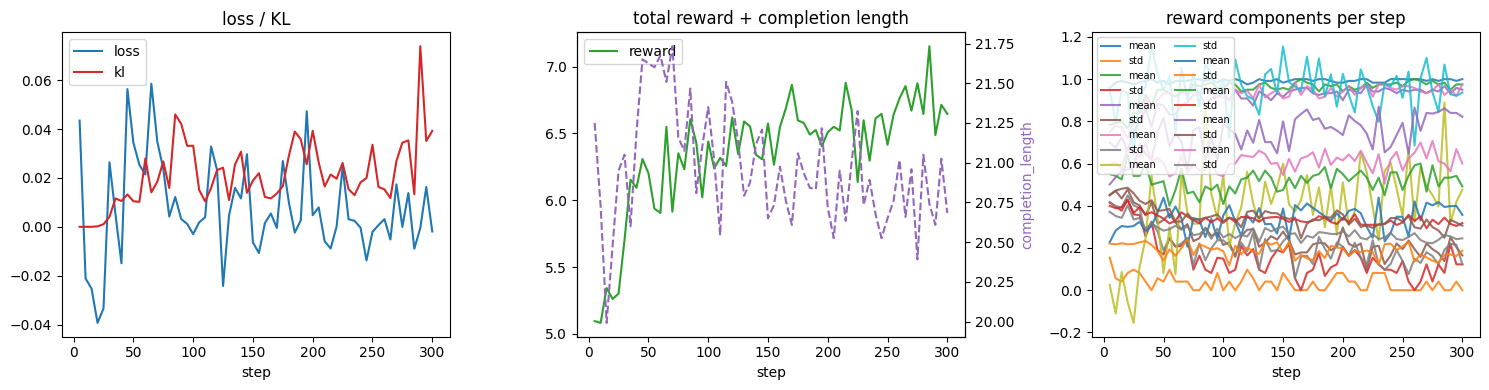

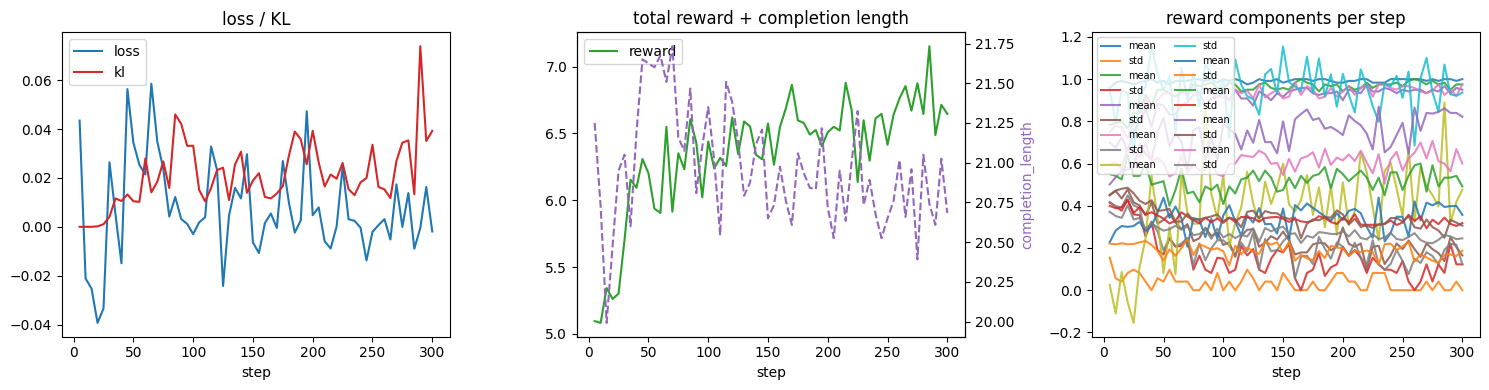

wrote _artifacts/training_diagnostics.png
wrote _artifacts/training_diagnostics.png


In [17]:
log = json.loads(TRAIN_LOG.read_text()) if TRAIN_LOG.exists() else {"history": []}
hist = log.get("history") or []

if not hist:
    print("no training log rows -- did GRPO train?")
else:
    df_log = pd.DataFrame(hist)
    if "step" not in df_log.columns:
        df_log["step"] = range(len(df_log))

    base_cols = ["loss", "kl", "reward", "completion_length", "grad_norm"]
    component_cols = [c for c in df_log.columns
                      if c.startswith("rewards/") or c in REWARD_NAMES
                      or any(c.endswith(name) for name in REWARD_NAMES)]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # panel 1: loss + kl
    for col, color in [("loss", "tab:blue"), ("kl", "tab:red")]:
        if col in df_log.columns and df_log[col].notna().any():
            axes[0].plot(df_log["step"], df_log[col], label=col, color=color)
    axes[0].set_title("loss / KL"); axes[0].set_xlabel("step"); axes[0].legend()

    # panel 2: total reward + completion length
    if "reward" in df_log.columns and df_log["reward"].notna().any():
        axes[1].plot(df_log["step"], df_log["reward"], label="reward", color="tab:green")
    if "completion_length" in df_log.columns and df_log["completion_length"].notna().any():
        ax2 = axes[1].twinx()
        ax2.plot(df_log["step"], df_log["completion_length"], label="completion_length",
                 color="tab:purple", linestyle="--")
        ax2.set_ylabel("completion_length", color="tab:purple")
    axes[1].set_title("total reward + completion length"); axes[1].set_xlabel("step")
    axes[1].legend(loc="upper left")

    # panel 3: per-reward-component breakdown
    if component_cols:
        for col in component_cols:
            if df_log[col].notna().any():
                short = col.split("/")[-1].replace("reward_", "")
                axes[2].plot(df_log["step"], df_log[col], label=short, alpha=0.85)
        axes[2].set_title("reward components per step")
        axes[2].set_xlabel("step")
        axes[2].legend(fontsize=7, ncol=2, loc="best")
    else:
        axes[2].set_title("(no per-component reward columns in log)")

    fig.tight_layout(); fig.savefig(TRAIN_DIAGNOSTICS, dpi=140); plt.show()
    print("wrote", TRAIN_DIAGNOSTICS)


## 9. Evaluate base LLM vs trained policy

1. **Base** `Qwen2.5-1.5B-Instruct` (no LoRA, same 4-bit load) on **all** scenarios
   — set `MODE["run_base_llm_eval"] = False` to skip and save time.
2. **Trained adapter** — reload through **Unsloth** so LoRA + fused attention match training.

Use `FastLanguageModel.from_pretrained` on `ADAPTER_DIR` after freeing VRAM from the base run.


In [18]:
from unsloth import FastLanguageModel

# Free training-only buffers if the kernel still has them.
for _name in ("model", "trainer"):
    if _name in globals():
        del globals()[_name]
gc.collect()
torch.cuda.empty_cache()

base_runs: dict = {}
if MODE.get("run_base_llm_eval", True):
    base_eval_model, base_tokenizer = FastLanguageModel.from_pretrained(
        model_name=MODEL_NAME,
        max_seq_length=MAX_PROMPT_LEN + MAX_NEW_TOKENS,
        dtype=None,
        load_in_4bit=True,
    )
    base_tokenizer.pad_token = base_tokenizer.pad_token or base_tokenizer.eos_token
    FastLanguageModel.for_inference(base_eval_model)

    @torch.inference_mode()
    def _base_llm_act(obs):
        msgs = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": render_observation(obs)},
        ]
        text = base_tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        inputs = base_tokenizer(text, return_tensors="pt").to(base_eval_model.device)
        out = base_eval_model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            pad_token_id=base_tokenizer.eos_token_id,
        )
        completion = base_tokenizer.decode(
            out[0][inputs.input_ids.shape[1]:], skip_special_tokens=True
        )
        a = parsed_action(completion)
        _base_llm_act._last_was_fallback = a is None
        return a or CybersecAction(action_type=ActionType.MONITOR)

    class BaseLLMPolicy:
        name = "qwen-1.5b-base"
        last_act_was_fallback = False
        def reset(self):
            self.last_act_was_fallback = False
        def act(self, obs):
            act_out = _base_llm_act(obs)
            self.last_act_was_fallback = bool(getattr(_base_llm_act, "_last_was_fallback", False))
            return act_out

    t0 = time.time()
    for sid in ALL_SCENARIOS:
        runs = [run_episode(env, BaseLLMPolicy(), seed=s, scenario_id=sid) for s in SEEDS_POST]
        base_runs[sid] = runs
        agg = aggregate_results(runs)
        std = float(np.std([r.cumulative_reward for r in runs]))
        print(f"[base-llm] {sid:<32s}  mean={agg['mean_return']:7.3f}  std={std:.3f}  "
              f"mon_fb={agg.get('monitor_fallback_rate', 0):.3f}")
    print(f"base-llm eval elapsed: {time.time()-t0:.1f}s")

    del base_eval_model, base_tokenizer
    gc.collect()
    torch.cuda.empty_cache()
else:
    print("skipping base-LLM eval (MODE['run_base_llm_eval'] is False)")

eval_model, eval_tokenizer = FastLanguageModel.from_pretrained(
    model_name=str(ADAPTER_DIR),
    max_seq_length=MAX_PROMPT_LEN + MAX_NEW_TOKENS,
    dtype=None,
    load_in_4bit=True,
)
eval_tokenizer.pad_token = eval_tokenizer.pad_token or eval_tokenizer.eos_token
FastLanguageModel.for_inference(eval_model)
print("loaded trained adapter via Unsloth for evaluation")


==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

...

Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

[base-llm] cloud_metadata_ssrf               mean=  5.194  std=0.000  mon_fb=0.000
base-llm eval elapsed: 267.9s
[base-llm] cloud_metadata_ssrf               mean=  5.194  std=0.000  mon_fb=0.000
base-llm eval elapsed: 267.9s
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: 

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
loaded trained adapter via Unsloth for evaluation
loaded trained adapter via Unsloth for evaluation


In [19]:
@torch.inference_mode()
def llm_act(obs):
    msgs = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": render_observation(obs)},
    ]
    text = eval_tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs = eval_tokenizer(text, return_tensors="pt").to(eval_model.device)
    out = eval_model.generate(
        **inputs,
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=False,
        pad_token_id=eval_tokenizer.eos_token_id,
    )
    completion = eval_tokenizer.decode(
        out[0][inputs.input_ids.shape[1]:], skip_special_tokens=True
    )
    a = parsed_action(completion)
    llm_act._last_was_fallback = a is None
    return a or CybersecAction(action_type=ActionType.MONITOR)

class TrainedLLMPolicy:
    name = "qwen-1.5b-grpo"
    last_act_was_fallback = False
    def reset(self):
        self.last_act_was_fallback = False
    def act(self, obs):
        out = llm_act(obs)
        self.last_act_was_fallback = bool(getattr(llm_act, "_last_was_fallback", False))
        return out

trained_runs = {}
t0 = time.time()
for sid in TRAIN_SCENARIOS:
    runs = [run_episode(env, TrainedLLMPolicy(), seed=s, scenario_id=sid) for s in SEEDS_POST]
    trained_runs[sid] = runs
    agg = aggregate_results(runs)
    print(f"{sid:<32s}  trained-llm={agg['mean_return']:7.3f}  "
          f"std={float(np.std([r.cumulative_reward for r in runs])):.3f}  "
          f"mon_fb={agg.get('monitor_fallback_rate', 0):.3f}")
print(f"trained-policy eval (train scenarios) elapsed: {time.time()-t0:.1f}s")


Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

supply_chain_token_drift          trained-llm=  5.202  std=0.000  mon_fb=0.000


Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

federated_identity_takeover       trained-llm=  1.399  std=0.817  mon_fb=0.000


Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

insider_repo_pivot                trained-llm=  5.178  std=0.000  mon_fb=0.000
trained-policy eval (train scenarios) elapsed: 358.9s


### 9a. Held-out OOD evaluation

The whole point of holding out `cloud_metadata_ssrf` from training is
this cell: a clean read on whether the trained policy *generalises* or
just memorised per-scenario plans.


In [20]:
heldout_runs = {}
t0 = time.time()
for sid in HELDOUT_SCENARIOS:
    runs = [run_episode(env, TrainedLLMPolicy(), seed=s, scenario_id=sid) for s in SEEDS_POST]
    heldout_runs[sid] = runs
    agg = aggregate_results(runs)
    rand_mean = aggregate_results(baseline_runs[sid]['random'])['mean_return']
    heur_mean = aggregate_results(baseline_runs[sid]['heuristic'])['mean_return']
    std = float(np.std([r.cumulative_reward for r in runs]))
    print(f"{sid:<32s}  trained-llm={agg['mean_return']:7.3f}  std={std:.3f}  "
          f"vs heur={heur_mean:.3f}  vs rand={rand_mean:.3f}")
print(f"trained-policy eval (held-out scenarios) elapsed: {time.time()-t0:.1f}s")

heldout_metrics = {
    sid: {
        "random":      aggregate_results(baseline_runs[sid]["random"]),
        "heuristic":   aggregate_results(baseline_runs[sid]["heuristic"]),
        "trained_llm": aggregate_results(heldout_runs[sid]),
    }
    for sid in HELDOUT_SCENARIOS
}
HELDOUT_JSON.write_text(json.dumps(heldout_metrics, indent=2))
print("wrote", HELDOUT_JSON)


Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

cloud_metadata_ssrf               trained-llm=  5.194  std=0.000  vs heur=2.552  vs rand=1.723
trained-policy eval (held-out scenarios) elapsed: 38.9s
wrote _artifacts/heldout_metrics.json


### 9c. Full-horizon trace (trained LLM)

Same table as §2c, but actions come from the **fine-tuned** policy (`TrainedLLMPolicy` + loaded adapter). Requires §9 cells to have run.

In [ ]:
print("--- trained LLM full-episode trace ---")
_ = run_and_print_episode_trace(
    env, TrainedLLMPolicy(), seed=0, scenario_id=TRAIN_SCENARIOS[0], obs_preview=200
)

## 10. Before/after curves on identical axes


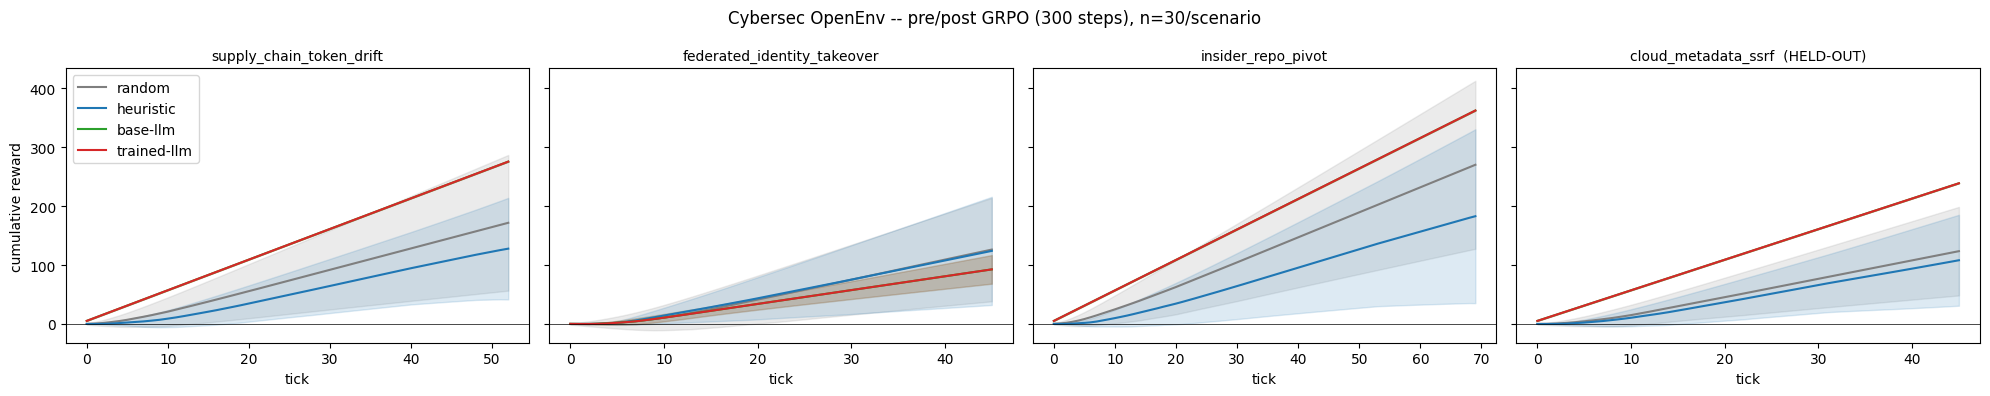

In [22]:
all_post = {**trained_runs, **heldout_runs}
panels = ALL_SCENARIOS
fig, axes = plt.subplots(1, len(panels), figsize=(5 * len(panels), 4), sharey=True)
if len(panels) == 1:
    axes = [axes]
for ax, sid in zip(axes, panels):
    cell = baseline_runs[sid]
    llm  = all_post.get(sid, [])
    base_ep = (base_runs or {}).get(sid, [])
    horizon = max(
        max(len(r.reward_curve) for r in cell['random']),
        max(len(r.reward_curve) for r in cell['heuristic']),
        max((len(r.reward_curve) for r in llm), default=1),
        max((len(r.reward_curve) for r in base_ep), default=1),
    )
    palette = [("random", cell['random'], "tab:gray"),
               ("heuristic", cell['heuristic'], "tab:blue"),
               ("base-llm", base_ep, "tab:green"),
               ("trained-llm", llm, "tab:red")]
    for label, runs, color in palette:
        if not runs:
            continue
        if label == "base-llm" and not base_runs:
            continue
        cumr = _padded_cumulative([r.reward_curve for r in runs], horizon)
        mean = cumr.mean(axis=0); std = cumr.std(axis=0)
        ax.plot(mean, label=label, color=color)
        ax.fill_between(np.arange(horizon), mean - std, mean + std, color=color, alpha=0.15)
    held_out_tag = "  (HELD-OUT)" if sid in HELDOUT_SCENARIOS else ""
    ax.set_title(sid + held_out_tag, fontsize=10); ax.set_xlabel("tick"); ax.axhline(0, color="k", lw=0.5)
axes[0].set_ylabel("cumulative reward"); axes[0].legend()
fig.suptitle(
    f"Cybersec OpenEnv -- pre/post GRPO ({MODE['grpo_max_steps']} steps), "
    f"n={MODE['n_post_train_episodes']}/scenario"
)
fig.tight_layout(); fig.savefig(BEFORE_AFTER, dpi=140); plt.show()


## 11. Summary table + headline delta


In [23]:
rows = []
for sid in ALL_SCENARIOS:
    cell = baseline_runs[sid]
    post_runs = all_post.get(sid, [])
    br = (base_runs or {}).get(sid, [])
    policy_rows = [
        ("random",      cell["random"]),
        ("heuristic",   cell["heuristic"]),
        ("base-llm",    br),
        ("trained-llm", post_runs),
    ]
    for policy_name, runs in policy_rows:
        if not runs:
            continue
        agg = aggregate_results(runs)
        returns = [r.cumulative_reward for r in runs]
        rows.append({
            "scenario":     sid,
            "split":        "held-out" if sid in HELDOUT_SCENARIOS else "train",
            "policy":       policy_name,
            "mean_return":  agg["mean_return"],
            "std_return":   round(float(np.std(returns)), 3) if returns else 0.0,
            "mean_stages":  agg["mean_stages_succeeded"],
            "exfil_rate":   agg["exfil_rate"],
            "invalid_rate": agg["mean_invalid_actions"],
            "mon_fallback":  agg.get("monitor_fallback_rate", 0.0),
        })
df = pd.DataFrame(rows)
print(df.to_string(index=False))

post_metrics = {
    sid: {
        "random":      aggregate_results(baseline_runs[sid]["random"]),
        "heuristic":   aggregate_results(baseline_runs[sid]["heuristic"]),
        "base_llm":     aggregate_results((base_runs or {}).get(sid, [])) if (base_runs or {}).get(sid) else None,
        "trained_llm": aggregate_results(all_post.get(sid, [])) if all_post.get(sid) else None,
    }
    for sid in ALL_SCENARIOS
}
post_metrics["_meta"] = {
    "n_post_episodes": MODE["n_post_train_episodes"],
    "grpo_max_steps":  MODE["grpo_max_steps"],
    "grpo_num_train_epochs": MODE.get("grpo_num_train_epochs", 1),
    "grpo_precision":    "fp16" if torch.cuda.is_available() else "fp32",
    "run_manifest":    str(RUN_MANIFEST),
    "model":           MODEL_NAME,
    "adapter":         str(ADAPTER_DIR),
    "run_base_llm_eval": bool(MODE.get("run_base_llm_eval", True)),
    "train_scenarios": TRAIN_SCENARIOS,
    "heldout_scenarios": HELDOUT_SCENARIOS,
    "reward_funcs":    REWARD_NAMES,
}
POST_JSON.write_text(json.dumps(post_metrics, indent=2))
SUMMARY_MD.write_text(df.to_markdown(index=False))
print("wrote", POST_JSON)
print("wrote", SUMMARY_MD)


                   scenario    split      policy  mean_return  std_return  mean_stages  exfil_rate  invalid_rate  mon_fallback
   supply_chain_token_drift    train      random        2.156       3.385        1.000       0.000           0.0           0.0
   supply_chain_token_drift    train   heuristic        2.335       3.288        1.800       0.100           0.0           0.0
   supply_chain_token_drift    train    base-llm        5.202       0.000        0.000       0.000           0.0           0.0
   supply_chain_token_drift    train trained-llm        5.202       0.000        0.000       0.000           0.0           0.0
federated_identity_takeover    train      random        0.198       3.939        1.100       0.000           0.0           0.0
federated_identity_takeover    train   heuristic        2.930       2.558        1.200       0.033           0.0           0.0
federated_identity_takeover    train    base-llm        1.399       0.817        0.933       0.000           0.

In [24]:
print("=== Headline delta (trained-llm vs heuristic) ===")
for sid in ALL_SCENARIOS:
    h = aggregate_results(baseline_runs[sid]["heuristic"])["mean_return"]
    runs = all_post.get(sid, [])
    if not runs:
        continue
    t = aggregate_results(runs)["mean_return"]
    tag = "(HELD-OUT)" if sid in HELDOUT_SCENARIOS else "(train)"
    print(f"{sid:<32s} {tag:<11s} heuristic={h:7.3f}  trained-llm={t:7.3f}  delta={t-h:+.3f}")


=== Headline delta (trained-llm vs heuristic) ===
supply_chain_token_drift         (train)     heuristic=  2.335  trained-llm=  5.202  delta=+2.867
federated_identity_takeover      (train)     heuristic=  2.930  trained-llm=  1.399  delta=-1.531
insider_repo_pivot               (train)     heuristic=  2.410  trained-llm=  5.178  delta=+2.768
cloud_metadata_ssrf              (HELD-OUT)  heuristic=  2.552  trained-llm=  5.194  delta=+2.642


## 12. Sanity assertions (strict canaries)

Includes aggregate heuristic-vs-random, valid-action rate, train-vs-random
floor, **≥2/3 training scenarios** with `std_return > 0.1` (iter-3/4
anti-collapse), and a cap on **MONITOR parse-fallback** rate for the
trained policy.


In [25]:
# 1. Reward shaping is healthy: heuristic must out-earn random *on aggregate*.
heur_total = sum(
    float(np.mean([r.cumulative_reward for r in cell['heuristic']]))
    for cell in baseline_runs.values()
)
rand_total = sum(
    float(np.mean([r.cumulative_reward for r in cell['random']]))
    for cell in baseline_runs.values()
)
print(f"baseline totals: heuristic={heur_total:+.3f}  random={rand_total:+.3f}")
assert heur_total > rand_total, (
    f"reward shaping regressed: heuristic total ({heur_total:.3f}) "
    f"<= random total ({rand_total:.3f}) summed across scenarios"
)

# 2. Trained policy must produce mostly-valid actions across all trained
#    episodes. Aggregate over train + held-out to keep one number.
total_steps = sum(len(r.reward_curve) for runs in all_post.values() for r in runs)
total_invalid = sum(r.invalid_action_count for runs in all_post.values() for r in runs)
valid_rate = 1.0 - (total_invalid / max(1, total_steps))
print(f"valid-action rate across all post-train episodes: {valid_rate:.1%}  "
      f"({total_invalid} invalid / {total_steps} steps)")
assert valid_rate >= 0.8, (
    f"trained policy is producing too many invalid actions ({valid_rate:.1%} valid)"
)

# 3. Trained policy must not be catastrophically worse than random on any
#    *training* scenario. (Held-out scenarios are allowed to be worse --
#    that's the point of generalisation reporting; we just print it.)
for sid in TRAIN_SCENARIOS:
    rand = float(np.mean([r.cumulative_reward for r in baseline_runs[sid]['random']]))
    llm  = float(np.mean([r.cumulative_reward for r in trained_runs[sid]]))
    assert llm >= rand - 5.0, (
        f"{sid}: trained-llm ({llm:.3f}) is more than 5 points below random "
        f"({rand:.3f}) -- training likely diverged"
    )

# 4. Strict reward-hack canary: std_return > 0.1 on at least (n_train - 1)
#    i.e. 2 of 3 training scenarios — catches iter-3/4 single-scenario variance.
non_zero_std_scenarios = []
for sid in TRAIN_SCENARIOS:
    returns = [r.cumulative_reward for r in trained_runs[sid]]
    s = float(np.std(returns))
    print(f"{sid:<32s}  trained-llm std_return={s:.4f}")
    if s > 0.1:
        non_zero_std_scenarios.append(sid)
_required = max(2, len(TRAIN_SCENARIOS) - 1)
assert len(non_zero_std_scenarios) >= _required, (
    f"REWARD HACK CANARY: trained-llm has std_return < 0.1 on "
    f"{len(TRAIN_SCENARIOS) - len(non_zero_std_scenarios)} of {len(TRAIN_SCENARIOS)} "
    f"training scenarios (non-zero: {non_zero_std_scenarios}). "
    f"Try raising grpo_num_generations / grpo_temperature, grpo_beta, or grpo_max_steps."
)

# 5. Parse / MONITOR fallback must stay bounded (unparseable JSON -> MONITOR).
total_fb = sum(r.monitor_fallback_count for runs in all_post.values() for r in runs)
fb_rate = total_fb / max(1, total_steps)
print(f"monitor_fallback rate (trained): {fb_rate:.1%}")
assert fb_rate <= 0.5, (
    f"trained-llm falls back to MONITOR on {fb_rate:.1%} of steps — check completions"
)

print("all sanity checks passed")


baseline totals: heuristic=+10.228  random=+6.981
valid-action rate across all post-train episodes: 100.0%  (0 invalid / 299 steps)
supply_chain_token_drift          trained-llm std_return=0.0000
federated_identity_takeover       trained-llm std_return=0.8174
insider_repo_pivot                trained-llm std_return=0.0000


AssertionError: REWARD HACK CANARY: trained-llm has std_return < 0.1 on 2 of 3 training scenarios (non-zero: ['federated_identity_takeover']). Try raising grpo_num_generations / grpo_temperature, grpo_beta, or grpo_max_steps.

## 13. (Optional) Push artifacts back to the HF Space

If you want the trained adapter and updated metrics to live on the HF
Space alongside the env (so the judges can diff `_artifacts/` between
iter-1 and iter-2), enable this cell. It uses the same
`huggingface_hub` API as the install cell.


In [ ]:
# Set this to True after a successful run if you want to upload artifacts.
PUSH_ARTIFACTS = False

if PUSH_ARTIFACTS:
    from huggingface_hub import HfApi
    api = HfApi()
    api.upload_folder(
        folder_path=str(ARTIFACTS),
        path_in_repo="_artifacts",
        repo_id=HF_SPACE_REPO_ID,
        repo_type="space",
        commit_message="iter-2 training artifacts",
    )
    print("uploaded _artifacts/ to", HF_SPACE_REPO_ID)
else:
    print("artifact push skipped (set PUSH_ARTIFACTS=True to enable)")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')